In [1]:
import sys
print(sys.executable)

c:\Projects\langchainupdated\.venv\Scripts\python.exe


In [2]:
import langchain 
print(langchain.__version__)

1.3.14


In [3]:
import langchain_google_genai
print(langchain_google_genai.__version__)

4.3.2


In [4]:
import langchain_groq
print(langchain_groq.__version__)

1.1.3


In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI

print("Gemini import successful!")


Gemini import successful!


In [8]:
import os
from dotenv import load_dotenv

from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0,
)

agent = create_agent(
    model=model,
    tools=[],
    system_prompt="You are a helpful assistant."
)

mdoel = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is LangChain?"
            }
        ]
    }
)

print(model)

c:\Projects\langchainupdated\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


metadata={'lc_versions': {'langchain-core': '1.5.2', 'langchain': '1.3.14', 'langchain-google-genai': '4.3.2'}} output_version=None profile={'name': 'Gemini 3.6 Flash', 'release_date': '2026-07-21', 'last_updated': '2026-07-21', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high'], 'reasoning_effort_default': 'medium'} google_api_key=SecretStr('**********') location=None model='gemini-3.6-flash' temperature=0.0 client=<google.genai.client.Client object at 0x000002B6BCABB450> default_metadata=() model_kwargs={}


In [9]:
from langchain_core.messages import HumanMessage

response = model.invoke(
    [HumanMessage(content="What is LangChain?")]
)

print(response.content)

c:\Projects\langchainupdated\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': '**LangChain** is an open-source software framework designed to simplify the process of building applications powered by Large Language Models (LLMs) like OpenAI’s GPT-4, Anthropic’s Claude, or open-source models like Llama.\n\nIf an LLM is the "brain," **LangChain acts as the glue and nervous system.** It connects the LLM to external data sources, software tools, databases, and APIs so it can perform complex, real-world tasks.\n\n---\n\n### Why is LangChain needed?\n\nOn their own, LLMs have limitations:\n1. **They don\'t know your private data:** They only know what they were trained on (public internet data up to a certain point).\n2. **They can\'t perform actions:** An LLM can write code, but it can\'t run it. It can write an email, but it can\'t send it.\n3. **They forget context:** Standard API calls to LLMs are stateless; they don\'t natively remember previous conversations unless you re-send the entire chat history.\n\nLangChain solves these problems b

In [10]:
from langchain.agents import create_agent

agent = create_agent(
    model=model,
    tools=[],
    system_prompt="You are a helpful assistant."
)

response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Explain AI agents in simple words."
            }
        ]
    }
)

print(response["messages"][-1].content)

c:\Projects\langchainupdated\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Think of an **AI agent** as a **digital assistant on autopilot**. \n\nInstead of just answering a question, an AI agent can **think, plan, and take action** to complete a goal for you without needing step-by-step instructions.\n\nHere is the easiest way to understand the difference between regular AI and an AI Agent:\n\n* **Regular AI (like a smart search engine):** You ask, *"What are good hotels in Paris?"* It gives you a list of hotels. **You** still have to do all the work to pick one, book it, and pay for it.\n* **AI Agent:** You tell it, *"Plan a 3-day trip to Paris for under $1,000."* The AI agent will check your calendar, search for flights, compare hotels, create a daily itinerary, and actually **book the tickets for you**.\n\n---\n\n### How an AI Agent Works (in 3 Simple Steps)\n\nAn AI agent operates in a continuous loop until its job is done:\n\n1. **Perceive:** It looks at the situation (e.g., reads your request, looks at a website, or checks you

In [12]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")



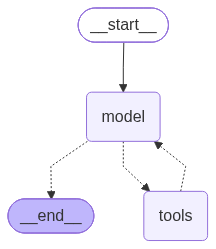

In [17]:
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

def get_whether(city:str)-> str:
    """Get the whether for a city."""
    return  f"The whether in {city} is sunny "

model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash"
)

agent = create_agent(
    model=model,
    tools=[get_whether],
    system_prompt="You are a helpful assistant"
)
agent

In [20]:
#run the agent.
response = agent.invoke({"messages":[{"role":"user","content":"What is the whether like in New York ?"}]})
response["messages"]

[HumanMessage(content='What is the whether like in New York ?', additional_kwargs={}, response_metadata={}, id='2e5ff0c5-9aaf-49ad-b1d0-cd41827c5074'),
 AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_whether', 'arguments': '{"city": "New York"}'}, '__gemini_function_call_thought_signatures__': {'xnV3yB9u': 'Eq0DCqoDARFNMg9l0/ewsxrIOjdocDSouCJMaW/Hrnlu/Q7J3hQ9rDjzSHNmv77jkpQ7mAc8jGISHp9afew4Z8J8ISVJcO4CkqY/FWSU9iQBCJWfwPugG1fIhEo3cd3DZpjho32JPs4mCCKJaN4vCSMMIyGxY+8752XvZbOiTpGEkyowtonXhoj2jbL4GaBfOmAN00e7uJr7rQ61sjiKxq86FZK7uBb42wYQC173gHGHAK2xcE8car19SEaaYo/rC2Reb97K2BgkDlW49knVLkr8cbFLhaHYCjdgAU9FZr3nuW/pQF57PXAP722sI1WnKO/7mJ90ps2OdXD3fFYqo6uYI6eeRsCSP0/nVye37zkJD6n4FNV1PZtCEUG2bYc9oA3yhFjMrzyuUKpMXixZzUG0KHdDrZqe5cOk4JUIVCRXomHP85KzaS8T6wfG/rWK6xz4Iksj6ZURgeVCWfwcYLcDZJR0EpZTlXaVUPoqpwFgMvVQZLVtUY3E6qdH06ZHm4lqaKnyWJBXu0LbX/RTpV/0MAXjGBxQQAZweMUBdxv6SJkYQF1Vx8u2XyRfCfIr'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.6-flash', 'safety

In [21]:
agent.invoke({"messages":"What is the whether in New York?"})

{'messages': [HumanMessage(content='What is the whether in New York?', additional_kwargs={}, response_metadata={}, id='8a7b7276-6929-449a-8e89-98e6f07fa3f3'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_whether', 'arguments': '{"city": "New York"}'}, '__gemini_function_call_thought_signatures__': {'ZmZyQn33': 'EqMDCqADARFNMg9Kf6OWKLoBSG9XuARRjshiBjMnjjwhHY8lxBsM4TH0IOZahTy0kyi/0XhA4i4XIeSlFnxkp/C83BeNfFgtrLOoAYtDSpLxgTjIzy5MAIaX4x+kJaNZO+Jzdhu21yUvwz9fbC5dzY/hBgjVsHsfjYxLjpn+kdVn0Iv8HhhFuru6XF/d4OpA/6T62f76GyXD8Ht4kGbPf/EY1SvpIW8MOjeFPwBX0EWQ7Magh2JWFcycE+QIQxFTleyFFdBzEPsSI8Eew7EQaPETLYJHyXFypz1XD3MIFqP/yc6Do6MS/afiF9G6n5HvoQlU8fxdwik8KCR7ogfM2yE0VNBot892hQcpCEECpJUYpbmh3R6XMgCVd8FTo7aFFLAqDSsfwXQzO+czj3Ih7ixTHBldZPihtq1y2a0lZI4ejUWVfmgHZErsNWoPSVcSG/MjiNvP6+QmU7pY4FmtQTBMsuGH1o7SEQwbPARXx5E9LQRqasKww1h7dNYM18rXwhkkurqrapcxZUnzKL3tq+fTtymig3ss6YfuWZNu37LS0Ntr1ZI='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.6-flash', 'safety_rat